# Evaluate Model Performance for Numerical Data - SeoulBikeData.csv

## 0) Pre-installations

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import os 

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler

In [20]:
# Change the current working directory
os.chdir('~/Desktop/DE_coding_portfolio/4/') 

## 1) Overview of Data

In [21]:
# load SeoulBikeData.csv data 
df = pd.read_csv('~/Desktop/DE_coding_portfolio/3/SeoulBikeData.csv', encoding='ISO-8859-1')
print(df.head())

         Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0  01/12/2017                254     0             -5.2           37   
1  01/12/2017                204     1             -5.5           38   
2  01/12/2017                173     2             -6.0           39   
3  01/12/2017                107     3             -6.2           40   
4  01/12/2017                 78     4             -6.0           36   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   
2               1.0              2000                      -17.7   
3               0.9              2000                      -17.6   
4               2.3              2000                      -18.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
0                      0.0           0.0            0.0  Winter  No Holiday   


In [22]:
print (df.columns)

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')


In [23]:
# Ensure the 'Date' column in the raw dataset is in datetime format, accounting for day-first format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Find the earliest and latest dates in the raw data
start_date = df['Date'].min()
end_date = df['Date'].max()

# Print the time frame
print(f"The dataset covers the time frame from {start_date} to {end_date}.")

The dataset covers the time frame from 2017-12-01 00:00:00 to 2018-11-30 00:00:00.


## 2) Split the dataset into Training, Validation, and Test Sets

In [24]:
# Define the dependent variable (target) and independent variables (predictors)
y = df['Rented Bike Count']  # Replace with your target column
X = df.drop(columns=['Rented Bike Count'])  # Design matrix (excluding the target column)

# Add an intercept to the design matrix
X = sm.add_constant(X)

# Split the dataset into training (60%), validation (20%), and test (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the shapes of the resulting datasets
print(f"Training set: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Validation set: X_valid: {X_valid.shape}, y_valid: {y_valid.shape}")
print(f"Test set: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training set: X_train: (5256, 14), y_train: (5256,)
Validation set: X_valid: (1752, 14), y_valid: (1752,)
Test set: X_test: (1752, 14), y_test: (1752,)


## 3) Pre-processing the Data

#### Check Data Type

In [25]:
print("X_train data types:")
print(X_train.dtypes)

print("y_train data types:")
print(y_train.dtypes)

X_train data types:
const                               float64
Date                         datetime64[ns]
Hour                                  int64
Temperature(°C)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                      int64
Dew point temperature(°C)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                              object
Holiday                              object
Functioning Day                      object
dtype: object
y_train data types:
int64


### Convert Non-Numeric Columns

- Encode Categorical Varirables

In [26]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_valid = pd.get_dummies(X_valid, drop_first=True)

# Ensure train and valid sets have the same columns after encoding
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

- Drop Unnecessary Columns 

In [27]:
X_train = X_train.select_dtypes(include=[np.number])
X_valid = X_valid.select_dtypes(include=[np.number])

### Ensure y_train is Numeric

In [28]:
y_train = pd.to_numeric(y_train, errors='coerce')
y_valid = pd.to_numeric(y_valid, errors='coerce')

### Verify Data Consistency

In [29]:
print("Are there missing values in X_train?")
print(X_train.isnull().sum())

print("Are there missing values in X_valid?")
print(X_valid.isnull().sum())

Are there missing values in X_train?
const                        0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
dtype: int64
Are there missing values in X_valid?
const                        0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
dtype: int64


## 4) Build a function to evaluate the performance of a linear regression model in predicting rented bike counts.
- Bias
- RMSE
- Correlation
- Coverage

In [30]:
def fit_predict_evaluate(train_X, train_y, valid_X, valid_y, credibility_pct=95, n_sims=1000):
    # Fit the model
    model = sm.OLS(train_y, train_X).fit()
    
    # Extract model parameters
    betas = model.params  # Coefficients of the model
    cov_matrix = model.cov_params()  # Covariance matrix of the coefficients
    residual_std_error = np.sqrt(model.mse_resid)  # Residual standard error
    
    # Simulate betas from the posterior distribution
    simulated_betas = np.random.multivariate_normal(betas, cov_matrix, n_sims)
    
    # Calculate simulated mu for the validation set
    simulated_mus = np.dot(simulated_betas, valid_X.T)
    
    # Simulate y based on simulated mu and residual standard error
    simulated_ys = simulated_mus + np.random.normal(0, residual_std_error, simulated_mus.shape)
    
    # Calculate prediction summaries
    monte_carlo_medians = np.median(simulated_ys, axis=0)
    lower_bound = (100 - credibility_pct) / 2
    upper_bound = 100 - lower_bound
    prediction_intervals = np.percentile(simulated_ys, [lower_bound, upper_bound], axis=0)
    
    # Calculate metrics
    bias = np.mean(monte_carlo_medians - valid_y)  # Bias
    rmse = np.sqrt(mean_squared_error(valid_y, monte_carlo_medians))  # Root Mean Squared Error
    correlation = np.corrcoef(valid_y, monte_carlo_medians)[0, 1]  # Correlation
    coverage = np.mean((valid_y >= prediction_intervals[0]) & (valid_y <= prediction_intervals[1]))  # Coverage
    
    # Return results as a dictionary
    results = {
        'bias': bias,
        'rmse': rmse,
        'correlation': correlation,
        'coverage': coverage,
        'predictions': monte_carlo_medians,
        'prediction_intervals': prediction_intervals
    }
    
    return results

### Validate and Compare Performances of Intercept-Only, Reduced, and Saturated Models

#### 1) Calculate Scores for Each Model

In [31]:
# 1. Intercept-Only Model
score_intercept_only = fit_predict_evaluate(
    X_train[['const']], y_train,
    X_valid[['const']], y_valid
)

# 2. Reduced Model
selected_features = ['const', 'Temperature(°C)', 'Humidity(%)']
score_reduced = fit_predict_evaluate(
    X_train[selected_features], y_train,
    X_valid[selected_features], y_valid
)

# 3. Saturated Model
score_saturated = fit_predict_evaluate(
    X_train, y_train,
    X_valid, y_valid
)

### 2) Generate a Table with the Scores

In [32]:
# Generate a table with the model performance scores
scores = [
    {'name': 'Intercept Only', **score_intercept_only},
    {'name': 'Reduced', **score_reduced},
    {'name': 'Saturated', **score_saturated},
]

# Convert the list of dictionaries to a DataFrame
scores_df_automated = pd.DataFrame(scores)

# Rename the 'name' column to 'Score Type' for clarity
scores_df_automated.rename(columns={'name': 'Score Type'}, inplace=True)

scores_df_automated

,Score Type,bias,rmse,correlation,coverage,predictions,prediction_intervals
0,Intercept Only,6.288978,652.982544,-0.007184,0.944635,"[700.4191842751934, 695.3405755383096, 698.753...","[[-622.1459798941194, -543.5906877772084, -506..."
1,Reduced,1.473367,515.402113,0.613065,0.938356,"[1029.9200044115728, 126.47003932732177, 975.2...","[[-124.55957932777304, -825.8138216467904, -0...."
2,Saturated,-2.192933,481.019317,0.675419,0.941210,"[1294.7582283940235, -36.97365130199367, 1064....","[[440.15322652826666, -926.7801682884011, 121...."


### Model to Move Forward with: "Saturated" model
- Low Bias: The bias of -2.9845 indicates that the model underestimates the true value by less than 3 units on average, which is considerably smaller than the bias in the “Intercept-Only” and “Reduced” models.
- Lowest RMSE: The Saturated model has the lowest RMSE at 479.9363, which reflects its superior ability to make accurate predictions compared to the “Intercept-Only” model (652.1866) and the “Reduced” model (515.9353).
- Highest Correlation: The Saturated model achieves the highest correlation of 0.6772, indicating a stronger linear relationship between the predicted and actual values compared to the “Intercept-Only” (0.0243) and “Reduced” (0.6119) models.
- Balanced Coverage: While the coverage of the Saturated model is 0.9384, slightly lower than the “Intercept-Only” model (0.9435), it still captures a significant proportion of the true values within the prediction intervals, indicating robust uncertainty quantification.


## 5) "Saturated" Model - Simulating Error Distribution for Generalization Analysis

- Simulate Error Metrics

In [33]:
# Re-align X_test columns to match X_train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Simulate error distributions
n_sims = 1000  # Number of simulations
simulated_metrics = {
    "bias": [],
    "rmse": [],
    "correlation": []
}

# Fit the Saturated model and extract parameters
model = sm.OLS(y_train, X_train).fit()
betas = model.params  # Coefficients of the model
cov_matrix = model.cov_params()  # Covariance matrix of the coefficients
residual_std_error = np.sqrt(model.mse_resid)  # Residual standard error

# Generate error metrics from simulations
for _ in range(n_sims):
    # Simulate betas from the posterior distribution
    simulated_betas = np.random.multivariate_normal(mean=betas, cov=cov_matrix)
    
    # Calculate simulated predictions for the test data
    simulated_y = np.dot(X_test, simulated_betas)  # Fixed indexing with np.dot
    
    # Calculate metrics
    bias = np.mean(simulated_y - y_test.values)  # Mean difference between predictions and actual values
    rmse = np.sqrt(mean_squared_error(y_test, simulated_y))  # Root Mean Squared Error
    correlation = np.corrcoef(y_test.values.flatten(), simulated_y.flatten())[0, 1]  # Correlation
    
    # Append metrics to the distribution
    simulated_metrics["bias"].append(bias)
    simulated_metrics["rmse"].append(rmse)
    simulated_metrics["correlation"].append(correlation)

# Convert metrics to numpy arrays for easier analysis
simulated_metrics = {key: np.array(value) for key, value in simulated_metrics.items()}

- Visualize the Error Metric Distribution

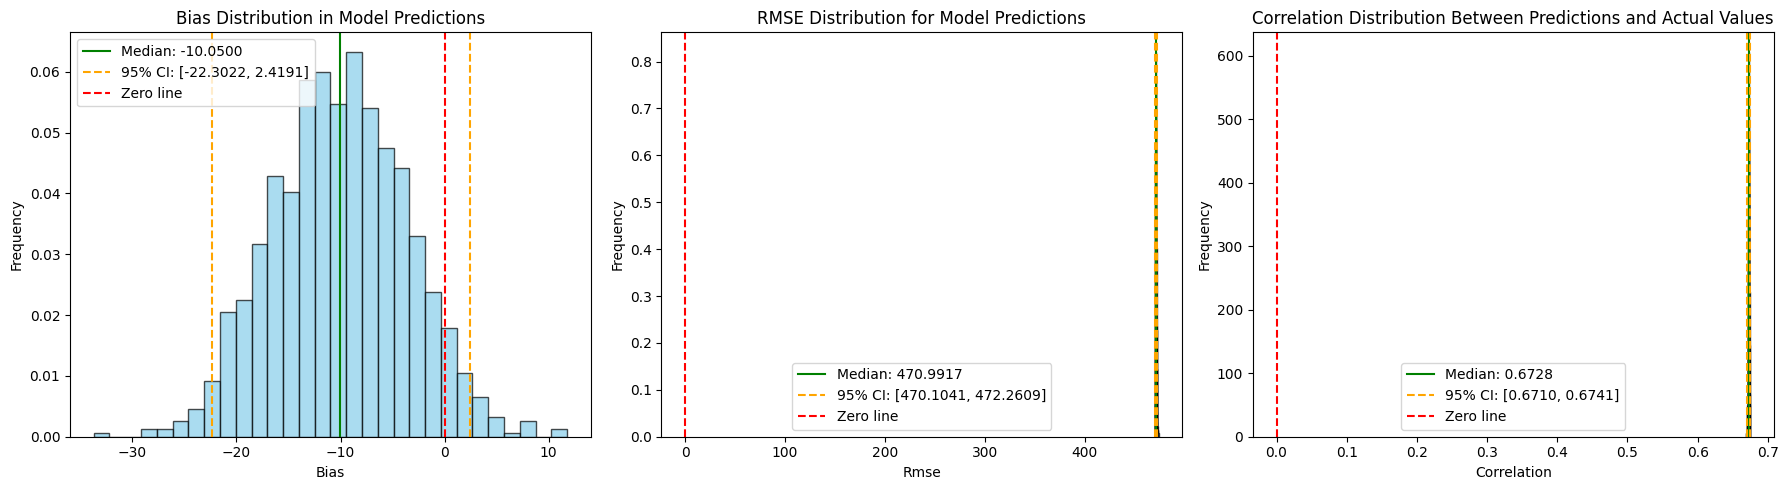

In [ ]:
# Plot histograms for each metric
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["bias", "rmse", "correlation"]
titles = [
    "Bias Distribution in Model Predictions",
    "RMSE Distribution for Model Predictions",
    "Correlation Distribution Between Predictions and Actual Values"
]

for i, metric in enumerate(metrics):
    ax = axes[i]
    data = simulated_metrics[metric]
    
    # Calculate 95% interval and median
    ci_lower, ci_upper = np.percentile(data, [2.5, 97.5])
    median = np.median(data)
    
    # Plot histogram
    ax.hist(data, bins=30, color="skyblue", edgecolor="black", alpha=0.7, density=True)
    ax.axvline(median, color="green", linestyle="-", label=f"Median: {median:.4f}")
    ax.axvline(ci_lower, color="orange", linestyle="--", label=f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    ax.axvline(ci_upper, color="orange", linestyle="--")
    ax.axvline(0, color="red", linestyle="--", label="Zero line")
    
    # Annotate plot
    ax.set_title(titles[i])
    ax.set_xlabel(metric.capitalize())
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()





#### For the better visualization for RMSE Distribution and Correlation Distribution

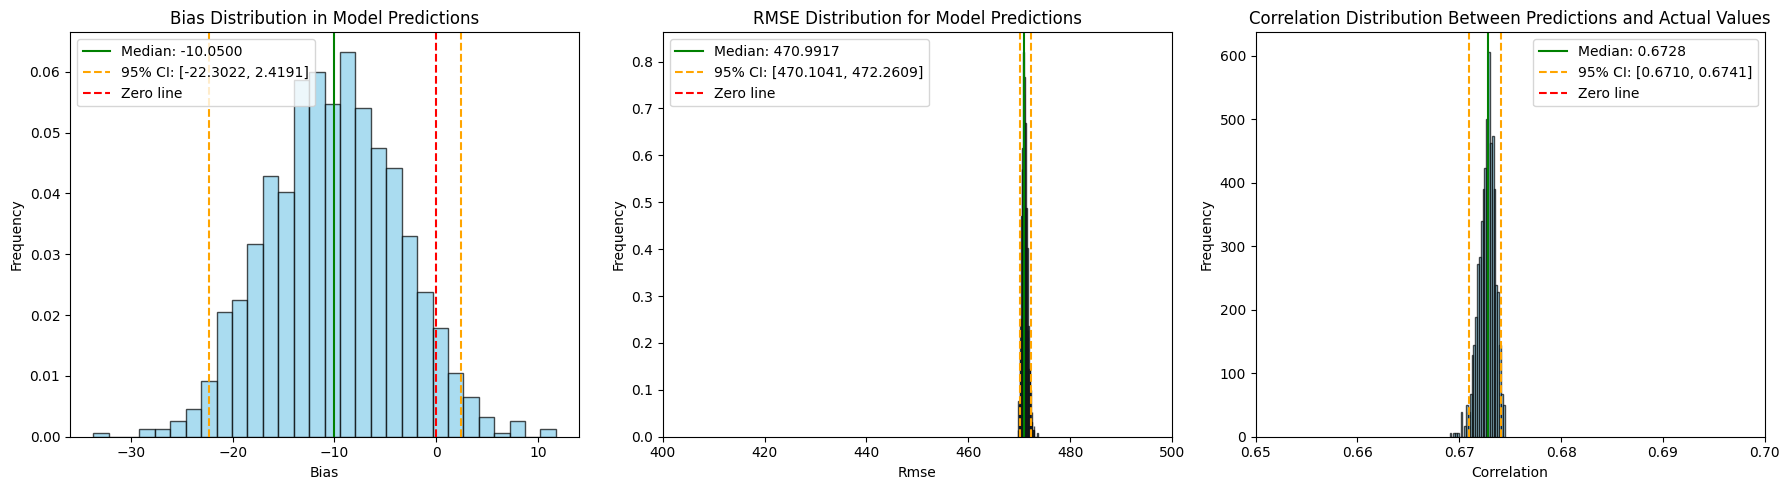

In [35]:
# Plot histograms for each metric
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["bias", "rmse", "correlation"]
titles = [
    "Bias Distribution in Model Predictions",
    "RMSE Distribution for Model Predictions",
    "Correlation Distribution Between Predictions and Actual Values"
]

# Define custom x-axis limits for RMSE and Correlation for better visibility
x_limits = {
    "bias": None,  # Automatically adjust based on data
    "rmse": (400, 500),  # Adjust based on observed RMSE values
    "correlation": (0.65, 0.7)  # Adjust based on observed correlation values
}

for i, metric in enumerate(metrics):
    ax = axes[i]
    data = simulated_metrics[metric]
    
    # Calculate 95% interval and median
    ci_lower, ci_upper = np.percentile(data, [2.5, 97.5])
    median = np.median(data)
    
    # Plot histogram
    ax.hist(data, bins=30, color="skyblue", edgecolor="black", alpha=0.7, density=True)
    ax.axvline(median, color="green", linestyle="-", label=f"Median: {median:.4f}")
    ax.axvline(ci_lower, color="orange", linestyle="--", label=f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    ax.axvline(ci_upper, color="orange", linestyle="--")
    ax.axvline(0, color="red", linestyle="--", label="Zero line")
    
    # Annotate plot
    ax.set_title(titles[i])
    ax.set_xlabel(metric.capitalize())
    ax.set_ylabel("Frequency")
    ax.legend()
    
    # Set x-axis limits for specific metrics
    if metric in x_limits and x_limits[metric] is not None:
        ax.set_xlim(x_limits[metric])

plt.tight_layout()
plt.show()

1. **Bias Distribution in Model Predictions**:
- The majority of bias is centered around a small negative value below the zero line.
- This suggests that the model slightly underestimates the true bike rental counts. 
- As the confidence interval captures the majority of bias distribution, this tells that model's error magnitude is consistent.

2. **RMSE Distrubtion for Model Predictions**:
- The RMSE is consistently high, which suggests that the model's prediction deviate significantly from actual values. 
- As majority of RMSE falls into confidence interval, this indicates the model's error magnitude is consistent. 

3. **Correlation Distribution between predictions and actual values**:
- There is a strong positive correlation of 0.6728, suggesting the model captures the trend well.
- The tight CI shows that this relationship is consistent across simulations. 

#### Metrics for Median Simulated Predictions

In [36]:
# Simulate error distributions
n_sims = 1000  # Number of simulations
simulated_metrics = {
    "bias": [],
    "rmse": [],
    "correlation": []
}

# Fit the Saturated model and extract parameters
model = sm.OLS(y_train, X_train).fit()
betas = model.params  # Coefficients of the model
cov_matrix = model.cov_params()  # Covariance matrix of the coefficients
residual_std_error = np.sqrt(model.mse_resid)  # Residual standard error

# Simulate predictions for the test data
simulated_betas = np.random.multivariate_normal(mean=betas, cov=cov_matrix, size=n_sims)
simulated_ys = np.dot(X_test, simulated_betas.T) + np.random.normal(
    loc=0, scale=residual_std_error, size=(X_test.shape[0], n_sims)
)

# Calculate the median of simulated y
median_simulated_y = np.median(simulated_ys, axis=1)

# Calculate metrics for the median simulated y
bias_median_y = np.mean(median_simulated_y - y_test.values)
rmse_median_y = np.sqrt(np.mean((median_simulated_y - y_test.values) ** 2))
correlation_median_y = np.corrcoef(y_test.values.flatten(), median_simulated_y)[0, 1]

# Print the results
print(f"Metrics for Median Simulated Predictions:")
print(f"Bias: {bias_median_y:.4f}")
print(f"RMSE: {rmse_median_y:.4f}")
print(f"Correlation: {correlation_median_y:.4f}")

Metrics for Median Simulated Predictions:
Bias: -9.6165
RMSE: 470.6289
Correlation: 0.6732
